In [1]:
from dotenv import load_dotenv

load_dotenv()
from typing import TypedDict, Literal, Annotated, List
from operator import add
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ToolNode
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool


In [2]:
@tool
def get_product_features(product_name: str):
    """Returns product feature information for the given product_name"""
    fake_db = {
        "Phone X": "durable build, vibrant display, fast processor",
        "Laptop Y": "lightweight design, long battery life, sharp screen",
    }
    return fake_db.get(product_name, "Product feature information not available.")


In [3]:
class InputState(TypedDict):
    review: str

class OutputState(TypedDict):
    agent_output: str

class OverallState(InputState, OutputState):
    messages: Annotated[List[BaseMessage], add]


In [4]:
tools = [get_product_features]
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash").bind_tools(tools)

def call_model_features(state: OverallState):
    local_messages = state.get("messages", [])
    if not local_messages:
        human_message = HumanMessage(content=state["review"])
        local_messages.append(human_message)
    system_message = SystemMessage(
        content="""You are a review agent. Add missing product features. 
If present, summarize them, otherwise fetch using tools. You must not ask any clarifiaction/cross question. Use your own intellegence and
fetch the information for the product from the available tool."""
    )
    response = model.invoke([system_message] + local_messages)
    state["agent_output"] = response.content
    state["messages"] = local_messages + [response]
    return state

def should_continue(state: OverallState) -> Literal["tools", END]:
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tools"
    return END


In [5]:
feature_graph = StateGraph(OverallState, input=InputState, output=OutputState)

feature_graph.add_node("call_model_features", call_model_features)
feature_graph.add_node("tools", ToolNode(tools))

feature_graph.add_edge(START, "call_model_features")
feature_graph.add_conditional_edges("call_model_features", should_continue)
feature_graph.add_edge("tools", "call_model_features")

feature_researcher_agent = feature_graph.compile()


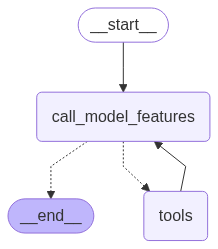

In [6]:
from IPython.display import Image, display
display(Image(feature_researcher_agent.get_graph().draw_mermaid_png()))

In [7]:
feature_researcher_agent.invoke(
    {"review": "I have recently bought an Phone X. It doesn't feel good."}
)


{'agent_output': 'The Phone X has a durable build, a vibrant display, and a fast processor.'}

In [8]:
sentiment_model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
def call_model_sentiment(state: OverallState):
    local_messages = state.get("messages", [])
    if not local_messages:
        local_messages.append(HumanMessage(content=state["review"]))
    system_message = SystemMessage(
        content="Clarify and correct sentiment in the review if unclear or neutral."
    )
    response = sentiment_model.invoke([system_message] + local_messages)
    state["agent_output"] = response.content
    state["messages"] = local_messages + [response]
    return state

sentiment_graph = StateGraph(OverallState, input=InputState, output=OutputState)
sentiment_graph.add_node("call_model_sentiment", call_model_sentiment)
sentiment_graph.add_edge(START, "call_model_sentiment")
sentiment_graph.add_edge("call_model_sentiment", END)
sentiment_agent = sentiment_graph.compile()


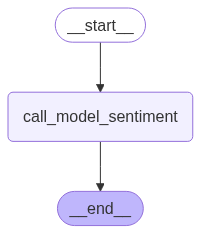

In [9]:
from IPython.display import Image, display
display(Image(sentiment_agent.get_graph().draw_mermaid_png()))

In [10]:
sentiment_agent.invoke(
{'review': "Phone X features a durable build, a vibrant display, and a fast processor. However, I understand that despite these features, you feel it doesn't have a premium feel."}
)

{'agent_output': 'The original statement "However, I understand that despite these features, you feel it doesn\'t have a premium feel" is an *interpretation* of a user\'s sentiment, not the user\'s direct review.\n\nTo make it sound like a direct review with clear sentiment, here are a few options:\n\n**Original (for context):**\n"Phone X features a durable build, a vibrant display, and a fast processor. However, I understand that despite these features, you feel it doesn\'t have a premium feel."\n\n---\n\n**Corrected & Clarified Options:**\n\n**Option 1 (Concise & Direct):**\n"Phone X features a durable build, a vibrant display, and a fast processor. **However, I found that it doesn\'t have a premium feel.**"\n*   **Sentiment:** Clearly positive on features, clearly negative on feel.\n*   **Correction:** Removes the interpretive "I understand that you feel" and attributes the feeling directly to the reviewer ("I found that").\n\n**Option 2 (Emphasizing the Contrast):**\n"Phone X featu

In [11]:
rewrite_review_model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
def expand_review_to_100_words(state: OverallState):
    human_message = HumanMessage(content=state["review"])
    system_message = SystemMessage(
        content="Rewrite this product review with more detail and ensure it exceeds 100 words. Do not cross question. Do not ask any clarification question. Use your imagination to complete the review in more than 100 words."
    )
    response = rewrite_review_model.invoke([system_message, human_message])
    state["agent_output"] = response.content
    return state

rewriter_graph = StateGraph(OverallState, input=InputState, output=OutputState)
rewriter_graph.add_node("expand_review_to_100_words", expand_review_to_100_words)
rewriter_graph.add_edge(START, "expand_review_to_100_words")
rewriter_graph.add_edge("expand_review_to_100_words", END)
rewriter_agent = rewriter_graph.compile()


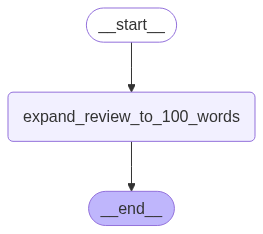

In [12]:
from IPython.display import Image, display
display(Image(rewriter_agent.get_graph().draw_mermaid_png()))

In [13]:
sentiment_agent.invoke(
        {'review': 'The sentiment is **mixed to slightly negative**.\n\nWhile the review highlights positive aspects like "durable build, vibrant display, and fast processor," the phrase "However, I understand that despite these features, you feel it doesn\'t have a premium feel" introduces a significant detractor. The "however" indicates that this lack of premium feel is a notable negative point that diminishes the overall positive impression of the features.\n\n**Correction/Clarification:**\n\n"The sentiment is **mixed, leaning negative** due to the perceived lack of a premium feel, which seems to overshadow the positive features for the user."'}
)

{'agent_output': 'Your analysis is accurate in identifying the mixed nature and the lean towards negativity.\n\n**Correction/Clarification:**\n\n"The sentiment is **mixed, but predominantly negative**. While positive features like \'durable build, vibrant display, and fast processor\' are acknowledged, the explicit statement that the lack of a \'premium feel\' is a \'significant detractor\' and \'diminishes the overall positive impression\' indicates that this negative aspect carries more weight and ultimately defines the user\'s overall dissatisfaction."'}

In [14]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

class ReviewEvaluator(BaseModel):
    on_topic: str = Field(description="Is the review about a product?")
    mentions_features: str = Field(description="Are product make and features (only consider: durability, appearance, battry life, screen, display) mentioned?")
    expresses_sentiment: str = Field(description="Does it express a clear opinion?")
    exceeds_100_words: str = Field(description="Does it have 100+ words?")

review_system = """
You are a grader evaluating a product review.
Return 'yes' or 'no' for the following:
1. Is the review about a product (only if it belongs to electronic gadgets)?
2. Are product make and features (only consider: durability, appearance, battery life, screen, display) mentioned?
3. Is the sentiment clear?
4. Does it exceed 100 words?
"""

grade_prompt = ChatPromptTemplate.from_messages(
    [("system", review_system), ("human", "{review}")]
)
grader = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.5).with_structured_output(ReviewEvaluator)
review_chef = grade_prompt | grader


In [15]:
review_chef.invoke({"review": "I have recently bought an Phone X. It doesn't feel good."})

ReviewEvaluator(on_topic='yes', mentions_features='no', expresses_sentiment='yes', exceeds_100_words='no')

In [16]:
class InputReviewState(TypedDict):
    review: str

class OutputFinalReviewState(TypedDict):
    final_review: str
    on_topic: str

class SharedReviewState(InputReviewState, OutputFinalReviewState):
    mentions_features: str
    expresses_sentiment: str
    exceeds_100_words: str


In [17]:
def update_review_state(state: SharedReviewState) -> SharedReviewState:
    response = review_chef.invoke({"review": state["review"]})
    state["on_topic"] = response.on_topic
    state["mentions_features"] = response.mentions_features
    state["expresses_sentiment"] = response.expresses_sentiment
    state["exceeds_100_words"] = response.exceeds_100_words
    return state


In [18]:
def feature_node(state: SharedReviewState) -> SharedReviewState:
    response = feature_researcher_agent.invoke({"review": state["review"]})
    state["review"] += f" {response['agent_output']}"
    return state

def sentiment_node(state: SharedReviewState) -> SharedReviewState:
    response = sentiment_agent.invoke({"review": state["review"]})
    state["review"] += f" {response['agent_output']}"
    return state

def rewrite_node(state: SharedReviewState) -> SharedReviewState:
    response = rewriter_agent.invoke({"review": state["review"]})
    state["review"] += f" {response['agent_output']}"
    state["final_review"] = response["agent_output"]
    return state


In [19]:
def review_decider(state: SharedReviewState) -> Literal[
    "feature_node", "sentiment_node", "rewrite_node", END
]:
    if state["on_topic"] == "no":
        return END
    if state["mentions_features"] == "no":
        return "feature_node"
    elif state["expresses_sentiment"] == "no":
        return "sentiment_node"
    elif (
        state["exceeds_100_words"] == "no"
        and state["mentions_features"] == "yes"
        and state["expresses_sentiment"] == "yes"
    ):
        return "rewrite_node"
    else:
        return END


In [20]:
workflow = StateGraph(SharedReviewState, input=InputReviewState, output=OutputFinalReviewState)

workflow.add_node("review_chef", update_review_state)
workflow.add_node("feature_node", feature_node)
workflow.add_node("sentiment_node", sentiment_node)
workflow.add_node("rewrite_node", rewrite_node)

workflow.set_entry_point("review_chef")

workflow.add_conditional_edges(
    "review_chef", review_decider,
    {
        "feature_node": "feature_node",
        "sentiment_node": "sentiment_node",
        "rewrite_node": "rewrite_node",
        END: END,
    }
)

workflow.add_edge("feature_node", "review_chef")
workflow.add_edge("sentiment_node", "review_chef")
workflow.add_edge("rewrite_node", "review_chef")

review_app = workflow.compile()


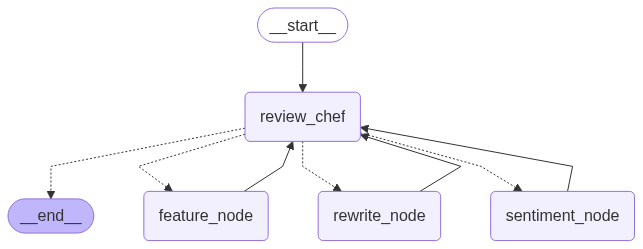

In [21]:
display(Image(review_app.get_graph().draw_mermaid_png()))

In [39]:
review_app.invoke({"review": "I have recently bought an Phone X. It doesn't feel good.."})


{'final_review': 'I recently purchased the Phone X, and while its specifications are undeniably impressive on paper, my personal experience with it has been surprisingly underwhelming. The Phone X certainly lives up to its promise of a durable build; it feels incredibly solid and robust, suggesting it could withstand everyday knocks with ease. The vibrant display is another highlight, rendering colors with stunning accuracy and making media consumption a truly immersive experience. Furthermore, the fast processor ensures that apps launch instantly and multitasking is buttery smooth, with no noticeable lag even under heavy loads.\n\nHowever, despite these strong technical merits, the phone simply "doesn\'t feel good" in my hand. The durable build, while reassuring, also contributes to a surprising heft that makes one-handed operation quite cumbersome. Its sleek design, though visually appealing, offers very little grip, leading to a constant fear of accidental slips. Even with the power

In [31]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

# Updated schema for review processing
class InputState(TypedDict):
    review: str

class IntermediateState(InputState):
    on_topic: str
    human_feedback: str
    enhanced_review: str

class FinalState(IntermediateState):
    api_response: str
    status_code: int

# Simply passes the initial review
def input_node(state: InputState) -> InputState:
    return state

# Calls the compiled review workflow
def review_processor_node(state: IntermediateState) -> IntermediateState:
    response = review_app.invoke({"review": state["review"]})
    print(response)
    state["enhanced_review"] = response.get(
        "final_review", "Review not relevant for publishing"
    )
    state["on_topic"] = response["on_topic"]
    return state

# Simulates an API submission with status and confirmation
def api_call_node(state: FinalState) -> FinalState:
    state["status_code"] = 200
    state["api_response"] = f"API received review: {state['human_feedback']}"
    return state

# Construct the stateful graph
workflow = StateGraph(FinalState, input=InputState, output=FinalState)

workflow.add_node("review_processor_node", review_processor_node)
workflow.add_node("api_call_node", api_call_node)

workflow.set_entry_point("review_processor_node")
workflow.add_edge("review_processor_node", "api_call_node")
workflow.add_edge("api_call_node", END)

# Compile with checkpoint for human-in-the-loop
human_review_app = workflow.compile(
    checkpointer=checkpointer,
    interrupt_after=["review_processor_node"]
)


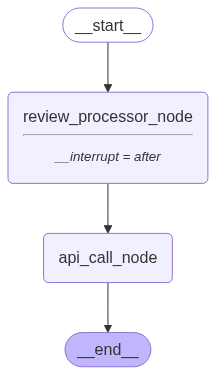

In [32]:
# Visualize the graph
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        human_review_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)


In [33]:

# Configs for threaded review
config1 = {"configurable": {"thread_id": "r1"}}

# First review is off-topic
human_review_app.invoke(
    {"review": "The weather is pleasant today in Berlin"},
    config=config1,
    subgraphs=True
)

{'on_topic': 'no'}


((),
 {'review': 'The weather is pleasant today in Berlin',
  'on_topic': 'no',
  'enhanced_review': 'Review not relevant for publishing'})

In [34]:
# Configs for threaded review
config2 = {"configurable": {"thread_id": "r2"}}

# Second review is relevant
human_review_app.invoke(
    {"review": "I recently bought Phone X. It doesn't feel good."},
    config=config2,
    subgraphs=True
)

{'final_review': 'Upon unboxing Phone X, my initial impression was somewhat mixed. While the device certainly boasts a remarkably durable build – the chassis feels incredibly solid and robust, instilling confidence that it could withstand the rigors of daily use – there\'s an elusive quality about its overall ergonomics that just doesn\'t quite "feel good" in the hand. Perhaps it\'s the specific weight distribution, or the texture of the back panel, but it lacks that seamless, comfortable fit I\'ve come to expect from modern smartphones.\n\nHowever, once you look past that tactile sensation, Phone X truly shines in its technical capabilities. The vibrant display is an absolute standout, offering stunning color reproduction, deep blacks, and impressive brightness, making everything from streaming high-definition videos to browsing photos a truly immersive experience. Furthermore, the inclusion of a fast processor ensures that performance is never an issue. Multitasking is incredibly flu

((),
 {'review': "I recently bought Phone X. It doesn't feel good.",
  'on_topic': 'yes',
  'enhanced_review': 'Upon unboxing Phone X, my initial impression was somewhat mixed. While the device certainly boasts a remarkably durable build – the chassis feels incredibly solid and robust, instilling confidence that it could withstand the rigors of daily use – there\'s an elusive quality about its overall ergonomics that just doesn\'t quite "feel good" in the hand. Perhaps it\'s the specific weight distribution, or the texture of the back panel, but it lacks that seamless, comfortable fit I\'ve come to expect from modern smartphones.\n\nHowever, once you look past that tactile sensation, Phone X truly shines in its technical capabilities. The vibrant display is an absolute standout, offering stunning color reproduction, deep blacks, and impressive brightness, making everything from streaming high-definition videos to browsing photos a truly immersive experience. Furthermore, the inclusion 

In [35]:
# Inspect and optionally modify the state
snapshot = human_review_app.get_state(config2)
existing_message = snapshot.values
print(existing_message)

{'review': "I recently bought Phone X. It doesn't feel good.", 'on_topic': 'yes', 'enhanced_review': 'Upon unboxing Phone X, my initial impression was somewhat mixed. While the device certainly boasts a remarkably durable build – the chassis feels incredibly solid and robust, instilling confidence that it could withstand the rigors of daily use – there\'s an elusive quality about its overall ergonomics that just doesn\'t quite "feel good" in the hand. Perhaps it\'s the specific weight distribution, or the texture of the back panel, but it lacks that seamless, comfortable fit I\'ve come to expect from modern smartphones.\n\nHowever, once you look past that tactile sensation, Phone X truly shines in its technical capabilities. The vibrant display is an absolute standout, offering stunning color reproduction, deep blacks, and impressive brightness, making everything from streaming high-definition videos to browsing photos a truly immersive experience. Furthermore, the inclusion of a fast 

In [36]:
# Optional manual edit before publishing
human_review_app.update_state(
    config2,
    {"human_feedback": "Not suitable for publication due to lack of sentiment clarity."},
)

{'configurable': {'thread_id': 'r2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f057904-e864-6bba-8002-bfd73950dd33'}}

In [37]:
# Resume the graph after manual review
human_review_app.invoke(None, config=config2)

{'review': "I recently bought Phone X. It doesn't feel good.",
 'on_topic': 'yes',
 'human_feedback': 'Not suitable for publication due to lack of sentiment clarity.',
 'enhanced_review': 'Upon unboxing Phone X, my initial impression was somewhat mixed. While the device certainly boasts a remarkably durable build – the chassis feels incredibly solid and robust, instilling confidence that it could withstand the rigors of daily use – there\'s an elusive quality about its overall ergonomics that just doesn\'t quite "feel good" in the hand. Perhaps it\'s the specific weight distribution, or the texture of the back panel, but it lacks that seamless, comfortable fit I\'ve come to expect from modern smartphones.\n\nHowever, once you look past that tactile sensation, Phone X truly shines in its technical capabilities. The vibrant display is an absolute standout, offering stunning color reproduction, deep blacks, and impressive brightness, making everything from streaming high-definition videos

In [38]:
# Final confirmation
snapshot = human_review_app.get_state(config2)
print(snapshot.values)


{'review': "I recently bought Phone X. It doesn't feel good.", 'on_topic': 'yes', 'human_feedback': 'Not suitable for publication due to lack of sentiment clarity.', 'enhanced_review': 'Upon unboxing Phone X, my initial impression was somewhat mixed. While the device certainly boasts a remarkably durable build – the chassis feels incredibly solid and robust, instilling confidence that it could withstand the rigors of daily use – there\'s an elusive quality about its overall ergonomics that just doesn\'t quite "feel good" in the hand. Perhaps it\'s the specific weight distribution, or the texture of the back panel, but it lacks that seamless, comfortable fit I\'ve come to expect from modern smartphones.\n\nHowever, once you look past that tactile sensation, Phone X truly shines in its technical capabilities. The vibrant display is an absolute standout, offering stunning color reproduction, deep blacks, and impressive brightness, making everything from streaming high-definition videos to

In [40]:
# Optional manual edit before publishing
human_review_app.update_state(
    config2,
    {"human_feedback": "Approved", "enhanced_review": "approve with these changes"},
)

{'configurable': {'thread_id': 'r2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f05791f-63ca-6f42-8004-b87a9361314b'}}

In [41]:
# Resume the graph after manual review
human_review_app.invoke(None, config=config2)

{'review': "I recently bought Phone X. It doesn't feel good.",
 'on_topic': 'yes',
 'human_feedback': 'Approved',
 'enhanced_review': 'approve with these changes',
 'api_response': 'API received review: Not suitable for publication due to lack of sentiment clarity.',
 'status_code': 200}

In [42]:
# Final confirmation
snapshot = human_review_app.get_state(config2)
print(snapshot.values)

{'review': "I recently bought Phone X. It doesn't feel good.", 'on_topic': 'yes', 'human_feedback': 'Approved', 'enhanced_review': 'approve with these changes', 'api_response': 'API received review: Not suitable for publication due to lack of sentiment clarity.', 'status_code': 200}
